# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

df = pd.read_csv('bread_basket.csv')

print(df.to_string()) 


       transaction                           item   date_time         time period_day weekday_weekend
0                1                          Bread  30/10/2016         9:58    morning         weekend
1                2                   Scandinavian  30/10/2016        10:05    morning         weekend
2                2                   Scandinavian  30/10/2016        10:05    morning         weekend
3                3                  Hot chocolate  30/10/2016        10:07    morning         weekend
4                3                            Jam  30/10/2016        10:07    morning         weekend
5                3                        Cookies  30/10/2016        10:07    morning         weekend
6                4                         Muffin  30/10/2016        10:08    morning         weekend
7                5                         Coffee  30/10/2016        10:13    morning         weekend
8                5                         Pastry  30/10/2016        10:13    morn

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [8]:
df.dtypes

transaction        int64
item                 str
date_time            str
time                 str
period_day           str
weekday_weekend      str
dtype: object

### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for Statistics.

In [9]:
# write your answer here
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

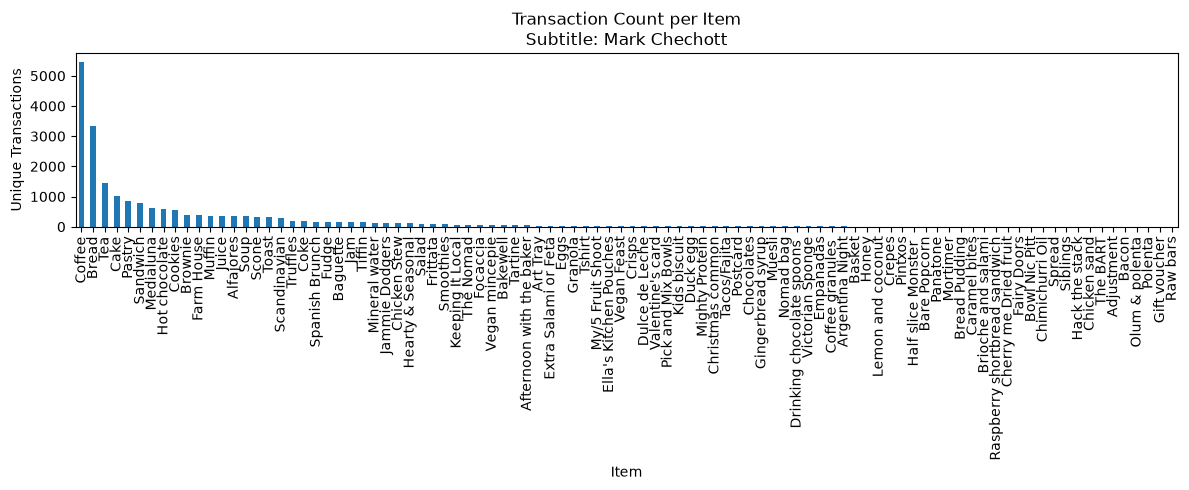

In [13]:
# c) Bar plot of transaction counts per item
subtitle = "Mark Chechott" 
item_counts = df['item'].value_counts()
item_counts = item_counts.sort_values(ascending=False)

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [40]:
# write your answer here
items = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']


df['item'].value_counts().reindex(items)

item
Coffee          5471
Tea             1435
Alfajores        369
Juice            369
Chicken Stew     123
Name: count, dtype: int64

## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.02) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [51]:
transactions = df.groupby('transaction')['item'].apply(list).tolist()

te = TransactionEncoder()

te_ary = te.fit(transactions).transform(transactions)

oht = pd.DataFrame(te_ary, columns=te.columns_).astype(bool)

oht.head()

freq_fp = fpgrowth(oht, min_support=0.02, use_colnames=True)
freq_fp.sort_values('support', ascending=False)

,support,itemsets
5,0.478394,frozenset({Coffee})
0,0.327205,frozenset({Bread})
8,0.142631,frozenset({Tea})
12,0.103856,frozenset({Cake})
19,0.090016,"frozenset({Bread, Coffee})"
6,0.086107,frozenset({Pastry})
13,0.071844,frozenset({Sandwich})
7,0.061807,frozenset({Medialuna})
2,0.058320,frozenset({Hot chocolate})
28,0.054728,"frozenset({Coffee, Cake})"


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [66]:


rules_fp = association_rules(freq_fp, metric='confidence', min_threshold=0.53)
rules_fp[['antecedents','consequents','support','confidence','lift']].sort_values('confidence', ascending=False)


,antecedents,consequents,support,confidence,lift
4,frozenset({Toast}),frozenset({Coffee}),0.023666,0.704403,1.472431
1,frozenset({Medialuna}),frozenset({Coffee}),0.035182,0.569231,1.189878
0,frozenset({Pastry}),frozenset({Coffee}),0.047544,0.552147,1.154168
2,frozenset({Juice}),frozenset({Coffee}),0.020602,0.534247,1.116750
3,frozenset({Sandwich}),frozenset({Coffee}),0.038246,0.532353,1.112792


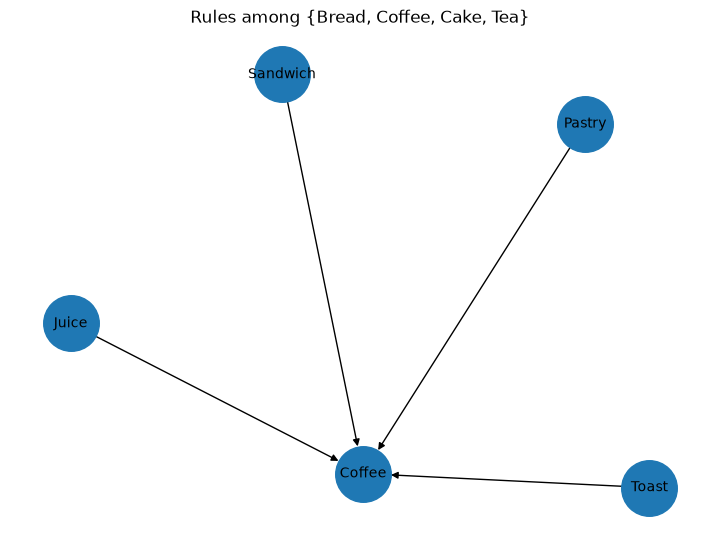

In [82]:
import networkx as nx

focus = {'Toast','Coffee','Pastry','Juice','Sandwich'}
sub = rules_fp[
    rules_fp['antecedents'].apply(lambda s: s.issubset(focus)) &
    rules_fp['consequents'].apply(lambda s: s.issubset(focus))
].copy()

G = nx.DiGraph()
for _, r in sub.iterrows():
    a = ','.join(sorted(list(r['antecedents'])))
    c = ','.join(sorted(list(r['consequents'])))
    G.add_edge(a, c, weight=float(r['confidence']), lift=float(r['lift']))

plt.figure(figsize=(7,5))
pos = nx.spring_layout(G, seed=0)
nx.draw(G, pos, with_labels=True, node_size=1600, font_size=10, arrows=True)
plt.title("Rules among {Bread, Coffee, Cake, Tea}")
plt.show()


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**


- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?

- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?

- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* 

The customers who purchase coffee and cake are likely to also purchase bread. A lift greater than 1 shows that there is a positive correlation. Meaning that bread is purchased with coffee and cake more often than would be expected based on breads overall purchase rate. 


>